# Shopping Dataset Analysis Project

Dataset loaded successfully with 1000 rows and 24 columns

Preview of data:


,product_id,title,product_description,rating,ratings_count,initial_price,discount,final_price,currency,images,...,amount_of_stars,what_customers_said,seller_name,sizes,videos,seller_information,variations,best_offer,more_offers,category
0,8376765,Lino Perros,Women Navy Blue Solid Backpack,3.8,15,3995,58.0,"""₹3,995.00""",INR,http://assets.myntassets.com/assets/images/837...,...,"{""1_star"":2,""2_stars"":0,""3_stars"":3,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-8376765_cae700""]",NaN,[{}],{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
1,9136281,Tommy Hilfiger,Unisex Navy Blue Striped Backpack,4.5,67,2899,35.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/913...,...,"{""1_star"":3,""2_stars"":4,""3_stars"":2,""4_stars"":...",NaN,NaN,"[{""size"":""Onesize""}]","[""rw-9136281_cae700""]",NaN,"[{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
2,17633752,Lavie,Aries Women Pink Mini Backpack,4.4,226,2999,65.0,"""₹2,999.00""",INR,http://assets.myntassets.com/assets/images/176...,...,"{""1_star"":9,""2_stars"":5,""3_stars"":10,""4_stars""...",NaN,NaN,"[{""size"":""S""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,"[{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
3,1376949,F Gear,Unisex Navy & Grey Printed Burner Backpack,4.4,1052,1675,52.0,"""₹1,675.00""",INR,http://assets.myntassets.com/assets/images/137...,...,"{""1_star"":33,""2_stars"":21,""3_stars"":69,""4_star...",NaN,NaN,"[{""size"":""Onesize""}]","[""https://videos.myntassets.com/assets/videos/...",NaN,NaN,{},"[{""offer_name"":""10% Instant Discount on Citi C...",backpacks
4,13939916,MYTRIDENT,Men Blue Solid Bath Robe,4.7,12,2899,17.0,"""₹2,899.00""",INR,http://assets.myntassets.com/assets/images/pro...,...,"{""1_star"":0,""2_stars"":0,""3_stars"":0,""4_stars"":...",NaN,NaN,"[{""size"":""M"",""value"":""45.0in"",""value_name"":""Fr...",NaN,NaN,"[{},{},{},{},{},{},{},{},{},{},{},{},{},{}]",{},"[{""offer_name"":""10% Instant Discount on IndusI...",bath-robe



Data types:
product_id                  int64
title                      object
product_description        object
rating                    float64
ratings_count               int64
initial_price               int64
discount                  float64
final_price                object
currency                   object
images                     object
delivery_options           object
product_details            object
breadcrumbs                object
product_specifications     object
amount_of_stars            object
what_customers_said        object
seller_name                object
sizes                      object
videos                     object
seller_information         object
variations                 object
best_offer                 object
more_offers                object
category                   object
dtype: object

Missing values per column:
product_id                  0
title                       0
product_description         0
rating                      0
ratings_c

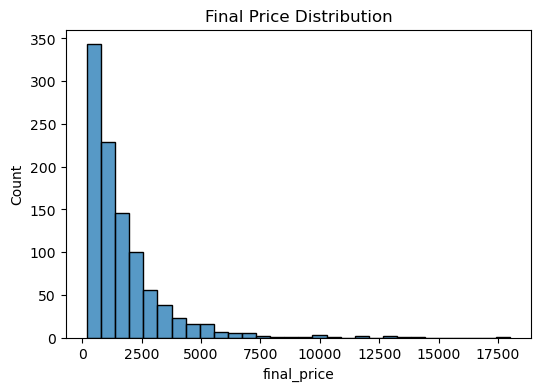

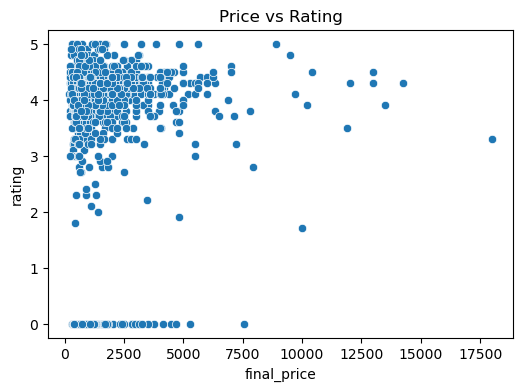

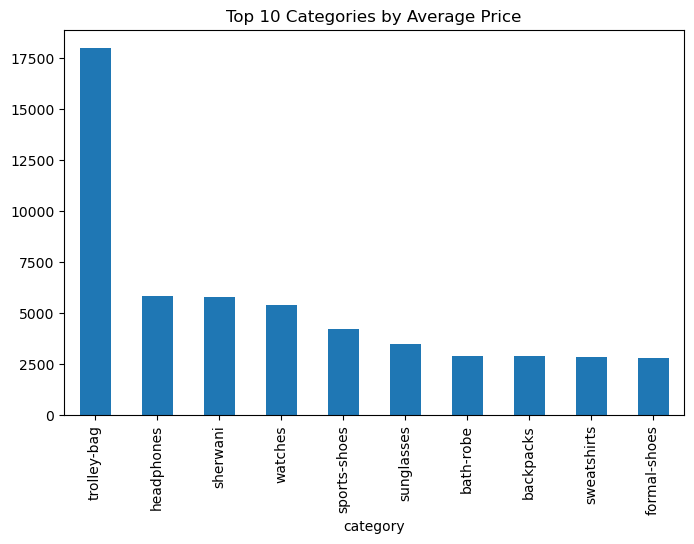

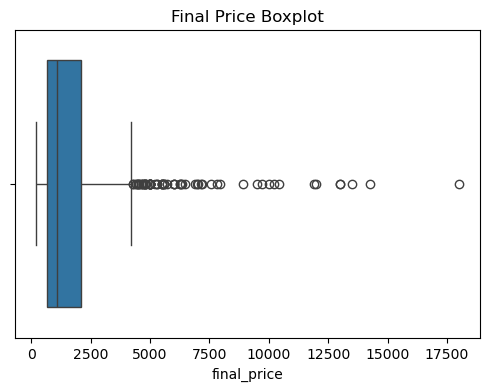


Key Insights:
Average price: 1706.1
Average rating: 3.62
Total revenue: 1706096.0
Average saving per product: 1017.14
Cleaned dataset saved at: C:\Users\TUF\Downloads\Data\Cleaned_Combined_dataset.csv

Final Summary:
Rows: 1000
Columns: 27
Missing values: 2639
Duplicate rows: 0
New columns added: price_difference, popularity, total_amount


In [2]:
# Shopping Dataset Analysis Project

# Step 1: Import libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from IPython.display import display

# Step 2: Load dataset
file_path = r"C:\Users\TUF\Downloads\Data\combined_dataset.csv"
df = pd.read_csv(file_path)

# Clean column names
df.columns = df.columns.str.strip().str.lower()
print("Dataset loaded successfully with", df.shape[0], "rows and", df.shape[1], "columns")

# Step 3: Explore data
print("\nPreview of data:")
display(df.head())
print("\nData types:")
print(df.dtypes)
print("\nMissing values per column:")
print(df.isnull().sum())

# Step 4: Handle missing values and duplicates
df.dropna(how='all', inplace=True)
df = df.drop_duplicates()

for col in ['initial_price','discount','final_price','rating','ratings_count']:
    if col in df.columns:
        df[col] = pd.to_numeric(df[col].astype(str).str.replace(r'[^0-9.\-]', '', regex=True), errors='coerce')

df.fillna({'rating': df['rating'].median(),
           'ratings_count': df['ratings_count'].median(),
           'category': 'Unknown'}, inplace=True)

print("Data cleaned successfully")

# Step 5: Feature engineering
if 'initial_price' in df.columns and 'final_price' in df.columns:
    df['price_difference'] = df['initial_price'] - df['final_price']

if 'rating' in df.columns and 'ratings_count' in df.columns:
    df['popularity'] = df['rating'] * df['ratings_count']

if 'final_price' in df.columns and 'quantity' in df.columns:
    df['total_amount'] = df['final_price'] * df['quantity']
else:
    df['total_amount'] = df['final_price']

print("New columns added: price_difference, popularity, total_amount")

# Step 6: Analysis
print("\nUnivariate Analysis:")
print(df['final_price'].describe())
print(df['rating'].describe())

print("\nBivariate Analysis (Price vs Rating correlation):")
print(df[['final_price','rating']].corr())

print("\nCategory-level Analysis (Average price per category):")
print(df.groupby('category')['final_price'].mean().sort_values(ascending=False).head(10))

# Step 7: Visualization
plt.figure(figsize=(6,4))
sns.histplot(df['final_price'], bins=30)
plt.title("Final Price Distribution")
plt.show()

plt.figure(figsize=(6,4))
sns.scatterplot(x='final_price', y='rating', data=df)
plt.title("Price vs Rating")
plt.show()

plt.figure(figsize=(8,5))
df.groupby('category')['final_price'].mean().sort_values(ascending=False).head(10).plot(kind='bar')
plt.title("Top 10 Categories by Average Price")
plt.show()

plt.figure(figsize=(6,4))
sns.boxplot(x=df['final_price'])
plt.title("Final Price Boxplot")
plt.show()

# Step 8: Insights
print("\nKey Insights:")
print("Average price:", round(df['final_price'].mean(),2))
print("Average rating:", round(df['rating'].mean(),2))
print("Total revenue:", round(df['total_amount'].sum(),2))
print("Average saving per product:", round(df['price_difference'].mean(),2))

# Step 9: Save cleaned dataset
output_path = r"C:\Users\TUF\Downloads\Data\Cleaned_Combined_dataset.csv"
df.to_csv(output_path, index=False)
print("Cleaned dataset saved at:", output_path)

# Step 10: Final Summary
print("\nFinal Summary:")
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])
print("Missing values:", df.isnull().sum().sum())
print("Duplicate rows:", df.duplicated().sum())
print("New columns added: price_difference, popularity, total_amount")